In [1]:
class Student:
    def __init__(self, name) -> None:
        self.__name = name

    @property
    def name(self):
        return self.__name

    @name.setter
    def name(self, value):
        self.__name = value



In [2]:

s1 = Student("Moaz")
s1.name = "Mezoo"
s1.name

'Mezoo'

In [ ]:
import numpy as np
vec = np.linspace(0,10,num = 25)
mat = vec.reshape(5,5)
mat

In [ ]:
I = np.identity(3,dtype="float64")
InterruptedError

In [3]:
import pandas as pd

s = pd.Series([1,2,3,4])
s

0    1
1    2
2    3
3    4
dtype: int64

In [4]:
s = pd.Series([1,2,3,4]), index =['a','b','c','d']
s

SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (1146001186.py, line 1)

In [9]:
data =[
    [1,444,'abc'],
    [2,555,'def'],
    [3,666,'ghf'],
    [4,444,'xyz']
]
df = pd.DataFrame(data,columns=["Idx","std_Id","Depart"])
df

,Idx,std_Id,Depart
0,1,444,abc
1,2,555,def
2,3,666,ghf
3,4,444,xyz


In [ ]:
import pandas as pd

df = pd.read_csv("Titanic.csv")

num_cols = df.select_dtypes("number").columns
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1
    lower_Fence = Q1-1.5*IQR
    upper_Fence = Q3+1.5*IQR
    print(Q1, Q3)

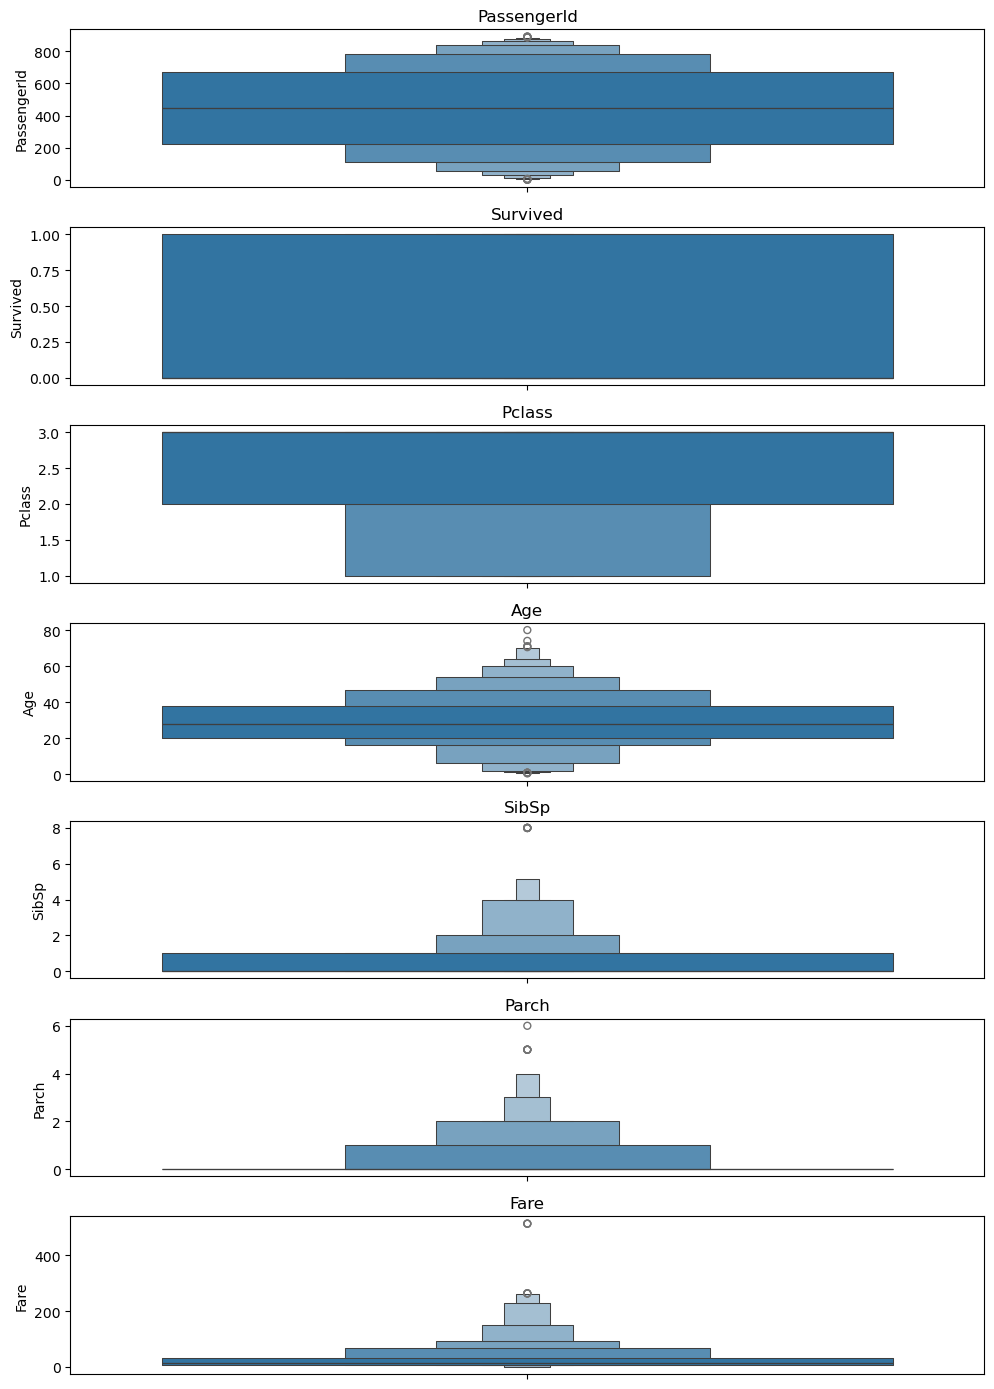

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

num_col = df.select_dtypes('number').columns

plt.figure(figsize=(10, 2 * len(num_col)))

for i, col in enumerate(num_col):
    plt.subplot(len(num_col), 1, i + 1)
    sns.boxenplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [11]:
num_col = df.select_dtypes('number').columns
for col in num_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5*IQR
    upper_fence = Q3 + 1.5 *IQR
   
    lower_outliers = df[   df[col] <      lower_fence]    [col].values
    upper_outliers = df[   df[col] >      upper_fence]    [col].values
    print(lower_outliers)


[]
[]
[]
[]
[]
[]
[]


In [ ]:
def plot_num_boxplot(df)


In [ ]:
def remove_duplicated_records(df, subset_cols = None, keep_strategy = "first"):
    return (df.drop_duplicates(subset=subset_cols, keep=keep_strategy).reset_index(drop = True))
 

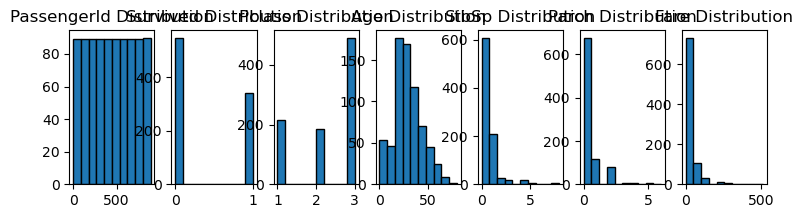

In [11]:
plt.figure(figsize=(9, 2))

for i, col in enumerate(num_col):
    plt.subplot(1, len(num_col), i + 1)
    plt.hist(df[col], edgecolor="black")
    plt.title(f"{col} Distribution")

plt.show()

In [14]:
cat_cols = ["Survived", "Pclass", "Sex", "SibSp", "Parch", "Embarked"]
df[cat_cols] = df[cat_cols].astype("category")

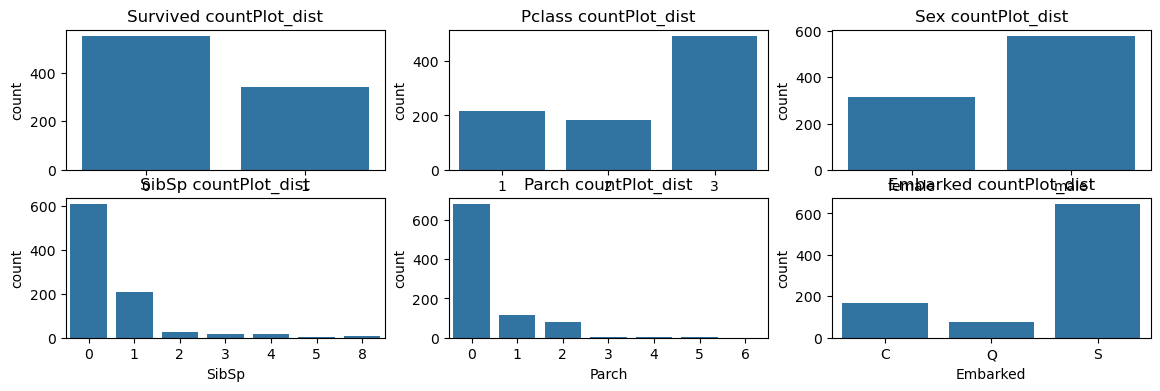

In [15]:
cat_cols = df.select_dtypes("category").columns
plt.figure(figsize=(14, 4))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3, i + 1)
    sns.countplot(x=col, data=df)
    plt.title(f"{col} countPlot_dist")

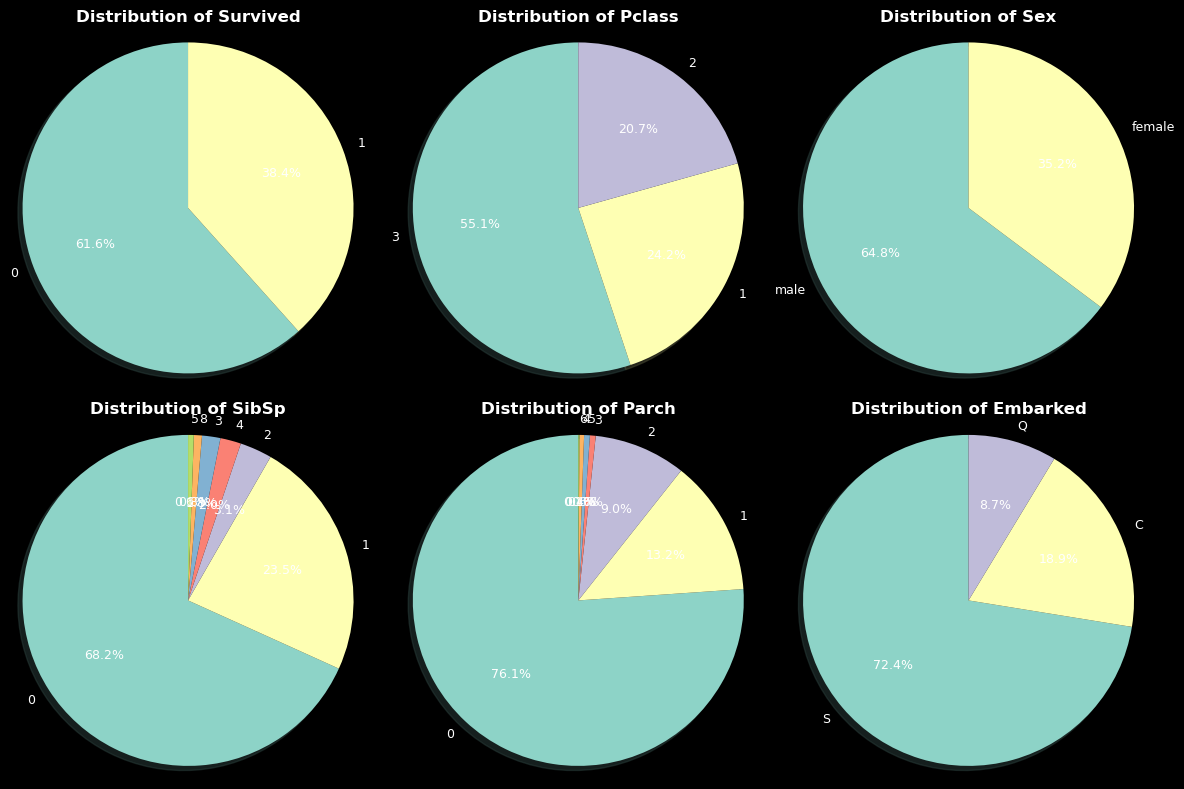

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for i, col in enumerate(cat_cols):

    plt.subplot(2, 3, i + 1)

    # Count each category
    unique = df[col].value_counts()

    count = unique.values
    categories = unique.index

    # Pie chart
    plt.pie(
        count,
        labels=categories,
        autopct='%1.1f%%',      # Show percentages
        startangle=90,
        shadow=True,
        textprops={'fontsize': 9}
    )

    plt.title(
        f'Distribution of {col}',
        fontsize=12,
        fontweight='bold'
    )

    plt.axis('equal')

plt.tight_layout()
plt.show()

In [ ]:
unique

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [ ]:
df['age'].clip

NameError: name 'df' is not defined

In [14]:
import pandas as pd

df = pd.read_csv("Titanic.csv")
x = df.drop("Survived",axis =1)
y =df[["survived"]]


KeyError: "None of [Index(['survived'], dtype='object')] are in the [columns]"

In [8]:
x.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [19]:
from sklearn.preprocessing import MinMaxScaler

num_cols = ['Age', 'Fare']
scaler = MinMaxScaler()
scaler.fit(x[num_cols])
x[num_cols] = scaler.transform(x[num_cols])
x[num_cols]

,Age,Fare
0,0.271174,0.014151
1,0.472229,0.139136
2,0.321438,0.015469
3,0.434531,0.103644
4,0.434531,0.015713
...,...,...
886,0.334004,0.025374
887,0.233476,0.058556
888,NaN,0.045771
889,0.321438,0.058556


In [20]:
str_cols=['sex','Embarked']

In [26]:
from category_encoders import OneHotEncoder

encoder = OneHotEncoder(
    cols=str_cols,
    drop_invariant=True
)

x = encoder.fit_transform(x)

ValueError: X does not contain the columns listed in cols

In [25]:
import sys
!{sys.executable} -m pip install category-encoders

  Using cached category_encoders-2.10.0-py3-none-any.whl.metadata (8.0 kB)
Using cached category_encoders-2.10.0-py3-none-any.whl (87 kB)


In [44]:
import plotly.express as px

fig.update_layout(
    # White background
    paper_bgcolor="white",
    plot_bgcolor="white",

    title=dict(
        text="<b> Titanic Survival Distribution</b>",
        x=0.5,
        xanchor="center",
        font=dict(
            size=26,
            family="Arial",
            color="#111827"
        )
    ),

    legend=dict(
        title=None,
        orientation="h",
        yanchor="bottom",
        y=-0.12,
        xanchor="center",
        x=0.5,
        font=dict(
            size=14,
            family="Arial",
            color="#374151"
        )
    ),

    margin=dict(
        t=90,
        b=80,
        l=50,
        r=50
    ),

    width=750,
    height=650
)

In [47]:
import plotly.express as px

# ==============================
# 1. Prepare Data
# ==============================

df_plot = df.copy()

df_plot["Survived"] = df_plot["Survived"].map({
    0: "Not Survived",
    1: "Survived"
})


# ==============================
# 2. Create Histogram
# ==============================

fig = px.histogram(
    df_plot,
    x="Sex",
    color="Survived",

    # Thin bars
    barmode="group",
    histnorm=None,

    # Black & Gold
    color_discrete_map={
        "Survived": "#D4AF37",       # Gold
        "Not Survived": "#171717"    # Black
    },

    text_auto=True
)


# ==============================
# 3. Improve Bars
# ==============================

fig.update_traces(
    marker=dict(
        line=dict(
            color="#D4AF37",
            width=1.5
        )
    ),

    textfont=dict(
        size=14,
        color="#F5F5F5"
    ),

    hovertemplate=(
        "<b>%{x}</b><br>"
        "Count: %{y}"
        "<extra></extra>"
    )
)


# ==============================
# 4. Layout
# ==============================

fig.update_layout(

    title=dict(
        text="<b>  Survival Distribution by Gender</b>",
        x=0.5,
        xanchor="center",
        font=dict(
            size=25,
            family="Arial",
            color="#D4AF37"
        )
    ),

    # X Axis
    xaxis=dict(
        title="<b>Gender</b>",
        showgrid=False,
        zeroline=False,
        tickfont=dict(
            size=14,
            color="#F5F5F5"
        ),
        title_font=dict(
            size=16,
            color="#D4AF37"
        )
    ),

    # Y Axis
    yaxis=dict(
        title="<b>Number of Passengers</b>",
        gridcolor="#333333",
        zeroline=False,
        tickfont=dict(
            size=13,
            color="#F5F5F5"
        ),
        title_font=dict(
            size=16,
            color="#D4AF37"
        )
    ),

    # Legend
    legend=dict(
        title=None,
        orientation="h",
        yanchor="bottom",
        y=-0.2,
        xanchor="center",
        x=0.5,
        font=dict(
            size=14,
            color="#F5F5F5"
        )
    ),

    # Premium dark background
    paper_bgcolor="#0B0B0B",
    plot_bgcolor="#121212",

    margin=dict(
        t=90,
        b=100,
        l=80,
        r=40
    ),

    width=800,
    height=600,

    # Add spacing between bars
    bargap=0.35,
    bargroupgap=0.12
)

fig.show()

In [49]:
import plotly.express as px

# Prepare data
df_plot = df.copy()

df_plot["Survived"] = df_plot["Survived"].map({
    0: "Not Survived",
    1: "Survived"
})

# Scatter Plot
fig = px.scatter(
    df_plot,
    x="Age",
    y="Fare",
    color="Survived",

    # Modern black & gold
    color_discrete_map={
        "Survived": "#D4AF37",      # Gold
        "Not Survived": "#555555"   # Dark Gray
    },

    title="<b>Age vs Fare by Survival</b>",

    labels={
        "Age": "Age",
        "Fare": "Fare",
        "Survived": "Survival Status"
    },

    opacity=0.75
)

# Improve points
fig.update_traces(
    marker=dict(
        size=9,
        line=dict(
            width=1,
            color="#FFFFFF"
        )
    ),

    hovertemplate=(
        "<b>Age:</b> %{x}<br>"
        "<b>Fare:</b> %{y}<br>"
        "<b>Status:</b> %{customdata}"
        "<extra></extra>"
    )
)

# Layout
fig.update_layout(

    title=dict(
        text="<b> Age vs Fare by Survival</b>",
        x=0.5,
        xanchor="center",
        font=dict(
            size=25,
            family="Arial",
            color="#D4AF37"
        )
    ),

    xaxis=dict(
        title="<b>Age</b>",
        showgrid=True,
        gridcolor="#333333",
        zeroline=False,
        tickfont=dict(
            color="#F5F5F5"
        ),
        title_font=dict(
            color="#D4AF37"
        )
    ),

    yaxis=dict(
        title="<b>Fare</b>",
        showgrid=True,
        gridcolor="#333333",
        zeroline=False,
        tickfont=dict(
            color="#F5F5F5"
        ),
        title_font=dict(
            color="#D4AF37"
        )
    ),

    legend=dict(
        title=None,
        orientation="h",
        yanchor="bottom",
        y=-0.2,
        xanchor="center",
        x=0.5,
        font=dict(
            size=14,
            color="#F5F5F5"
        )
    ),

    paper_bgcolor="#0B0B0B",
    plot_bgcolor="#121212",

    margin=dict(
        t=90,
        b=100,
        l=80,
        r=40
    ),

    width=850,
    height=600
)

fig.show()